In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Jansen-Rit Model

The **Jansen-Rit model** simulates EEG-like activity from a cortical column built from three interacting populations — pyramidal cells, excitatory interneurons, and inhibitory interneurons. Each population is a second-order linear filter (post-synaptic potential) followed by a sigmoidal firing-rate nonlinearity. For a range of external input rates the column produces alpha-band (~10 Hz) oscillations, making it a standard generative model of scalp EEG.

**Reference:** Jansen & Rit (1995), *Electroencephalogram and visual evoked potential generation in a mathematical model of coupled cortical columns*, Biological Cybernetics 73(4):357-366.

## Build the model

In [2]:
node = brainmass.JansenRitStep(in_size=1)
node

JansenRitStep(
  in_size=(1,),
  out_size=(1,),
  Ae=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(3.25, "mV")
  ),
  Ai=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(22., "mV")
  ),
  be=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(100., "Hz")
  ),
  bi=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(50., "Hz")
  ),
  a1=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  ),
  a2=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.8, dtype=float32)
  ),
  a3=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.25, dtype=float32)
  ),
  a4=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.25, dtype=float32)
  ),
  v0=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Quantity(6., "mV")
  ),
  C=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(135., dtype=floa

## Run a simulation

The model is driven by an external pyramidal input rate `E_inp`. The EEG proxy is the pyramidal membrane potential `M`.

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(2000. * u.ms,
              inputs=lambda i, t: (0. * u.mV, 220. * u.Hz, 0. * u.mV),
              monitors=['M'], transient=500. * u.ms)
res['M'].shape

(15000, 1)

## Visualize

The pyramidal potential `M` oscillates in the alpha band — the Jansen-Rit EEG proxy.

/tmp/ipykernel_2209881/623381096.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axes[1].set_title('Power spectrum'); axes[1].set_xlim(0, 40)


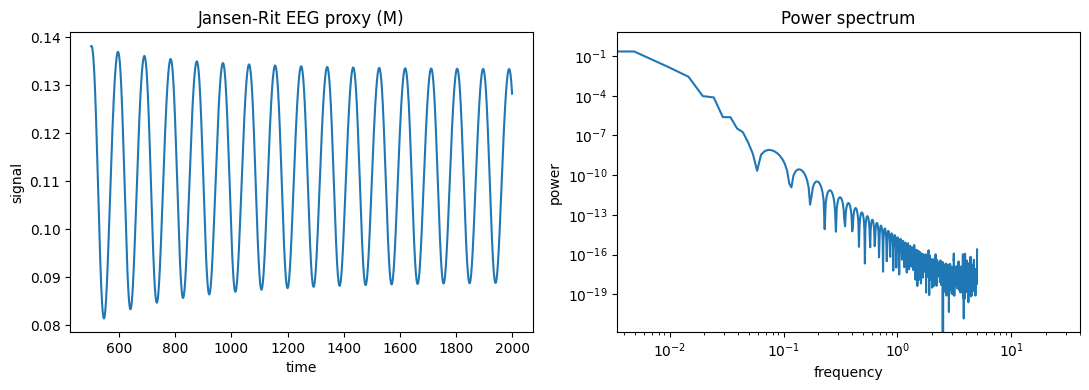

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
brainmass.viz.plot_timeseries(res['M'], ts=res['ts'], ax=axes[0])
axes[0].set_title('Jansen-Rit EEG proxy (M)')
brainmass.viz.plot_power_spectrum(res['M'][:, 0], dt=0.1 * u.ms, ax=axes[1])
axes[1].set_title('Power spectrum'); axes[1].set_xlim(0, 40)
plt.tight_layout()
plt.show()

## Try it: vary the external input rate `p`

The mean input rate to the pyramidal population sets the regime; in the classic band (~120-320 Hz) the column produces alpha-like rhythms, and outside it the dynamics change qualitatively.

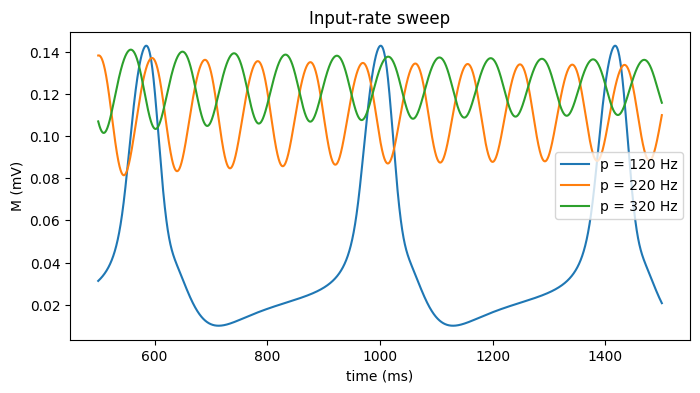

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for p in [120., 220., 320.]:
    m = brainmass.JansenRitStep(in_size=1)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        1500. * u.ms,
        inputs=lambda i, t, pp=p: (0. * u.mV, pp * u.Hz, 0. * u.mV),
        monitors=['M'], transient=500. * u.ms)
    ax.plot(u.get_magnitude(r['ts']), u.get_magnitude(r['M'])[:, 0], label=f'p = {p:.0f} Hz')
ax.set_xlabel('time (ms)'); ax.set_ylabel('M (mV)'); ax.legend()
ax.set_title('Input-rate sweep')
plt.show()